In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

In [ ]:
data = pd.read_csv("player_stats_clean.csv")

In [ ]:
data = data[data['total_plays']>200]

In [ ]:
data.head()

,season,player_name,total_plays,total_yards,total_tds,total_epa,avg_epa_per_play,pass_attempts,completions,pass_yards,...,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,draft_year,draft_round,draft_overall
0,2018,T.Brady,782,5183,33,135.347554,0.173079,716,460,5308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,D.Brees,659,4418,40,182.199677,0.276479,589,418,4542,...,50.0,25.0,27.0,0.141,78.781038,39.390519,42.541761,2001.0,2.0,32.0
4,2018,E.Manning,667,3967,23,41.028712,0.061512,627,380,4299,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2018,B.Roethlisberger,775,5069,38,154.389430,0.199212,701,452,5129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018,P.Rivers,688,4610,37,127.311625,0.185046,636,394,4799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Underperforming and Overperforming Contracts - QBs**

In [ ]:
data_qb = data[data['position.x'] == 'QB']

In [ ]:
data.columns

Index(['season', 'player_name', 'total_plays', 'total_yards', 'total_tds',
       'total_epa', 'avg_epa_per_play', 'pass_attempts', 'completions',
       'pass_yards', 'pass_tds', 'interceptions', 'sacks', 'air_yards_total',
       'yac_total', 'qb_epa_total', 'cpoe_avg', 'rush_attempts', 'rush_yards',
       'rush_tds', 'rush_epa_total', 'rush_success_rate', 'fumbles',
       'fumbles_lost', 'tackles_for_loss', 'first_down_rushes', 'avg_rush_epa',
       'receptions', 'targets', 'rec_yards', 'rec_tds', 'air_yards_rec',
       'yac_rec', 'rec_epa_total', 'yac_epa_total', 'air_epa_total',
       'rec_success_rate', 'position.x', 'latest_team', 'years', 'value',
       'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value', 'inflated_apy',
       'inflated_guaranteed', 'draft_year', 'draft_round', 'draft_overall'],
      dtype='object')

In [ ]:
# Convert numeric columns
numeric_cols = [
    "inflated_apy", "total_epa", "avg_epa_per_play", "total_yards", "total_tds",
    "pass_yards", "pass_tds", "interceptions", "sacks",
    "qb_epa_total", "cpoe_avg", "rush_epa_total"
]
for col in numeric_cols:
    data_qb[col] = pd.to_numeric(data_qb[col], errors="coerce")

/tmp/ipython-input-3553458463.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_qb[col] = pd.to_numeric(data_qb[col], errors="coerce")


In [ ]:
# Efficiency per million dollars
data_qb["epa_per_million"] = data_qb["total_epa"] / (data_qb["inflated_apy"] / 1e6)
data_qb["yards_per_million"] = data_qb["total_yards"] / (data_qb["inflated_apy"] / 1e6)
data_qb["tds_per_million"] = data_qb["total_tds"] / (data_qb["inflated_apy"] / 1e6)

# Additional QB-specific $-efficiency stats
data_qb["pass_tds_per_million"] = data_qb["pass_tds"] / (data_qb["inflated_apy"] / 1e6)
data_qb["int_per_million"] = data_qb["interceptions"] / (data_qb["inflated_apy"] / 1e6)
data_qb["sacks_per_million"] = data_qb["sacks"] / (data_qb["inflated_apy"] / 1e6)
data_qb["td_per_int"] = data_qb["pass_tds"] / data_qb["interceptions"].replace(0, pd.NA)

# Normalize by position (Z-score within QBs)
data_qb["epa_z"] = (data_qb["epa_per_million"] - data_qb["epa_per_million"].mean()) / data_qb["epa_per_million"].std()
data_qb["yards_z"] = (data_qb["yards_per_million"] - data_qb["yards_per_million"].mean()) / data_qb["yards_per_million"].std()
data_qb["tds_z"] = (data_qb["tds_per_million"] - data_qb["tds_per_million"].mean()) / data_qb["tds_per_million"].std()


/tmp/ipython-input-1106831585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_qb["epa_per_million"] = data_qb["total_epa"] / (data_qb["inflated_apy"] / 1e6)
/tmp/ipython-input-1106831585.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_qb["yards_per_million"] = data_qb["total_yards"] / (data_qb["inflated_apy"] / 1e6)
/tmp/ipython-input-1106831585.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [ ]:
# Composite Cap Efficiency Index
data_qb["cap_efficiency_index"] = (
    0.5 * data_qb["epa_per_million"].rank(pct=True) +
    0.3 * data_qb["yards_per_million"].rank(pct=True) +
    0.2 * data_qb["tds_per_million"].rank(pct=True)
)

/tmp/ipython-input-4080813179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_qb["cap_efficiency_index"] = (


In [ ]:
# Predictive Model
model_features = [
    "total_epa", "total_yards", "epa_z", "tds_z",
    "td_per_int", "qb_epa_total", "avg_epa_per_play", "cpoe_avg", "rush_epa_total"
]

In [ ]:
model_df = data_qb.dropna(subset=model_features + ["inflated_apy"])
X = model_df[model_features]
y = model_df["inflated_apy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
r2 = reg.score(X_test, y_test)
print(f"Model R² = {r2:.3f}")

Model R² = 0.261


In [ ]:
#Calculate Predicted APY and Value Gap
model_df["predicted_apy"] = reg.predict(X)
model_df["value_gap"] = model_df["predicted_apy"] - model_df["inflated_apy"]


/tmp/ipython-input-3204210044.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["predicted_apy"] = reg.predict(X)
/tmp/ipython-input-3204210044.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["value_gap"] = model_df["predicted_apy"] - model_df["inflated_apy"]


In [ ]:
#Identify Overperformers & Underperformers
underpaid = model_df.sort_values("value_gap", ascending=False).head(5)[
    ["season", "player_name", "inflated_apy", "predicted_apy", "value_gap"]
]

overpaid = model_df.sort_values("value_gap", ascending=True).head(5)[
    ["season", "player_name", "inflated_apy", "predicted_apy", "value_gap"]
]

print("\n Top 5 Most Underpaid QBs:")
print(underpaid.to_string(index=False))

print("\n Top 5 Most Overpaid QBs:")
print(overpaid.to_string(index=False))


 Top 5 Most Underpaid QBs:
 season player_name  inflated_apy  predicted_apy  value_gap
   2023      J.Love     16.766904      46.449924  29.683020
   2023    C.Stroud     11.264641      40.845225  29.580584
   2020   J.Herbert      9.360228      37.589984  28.229756
   2023  B.Mayfield      4.967972      30.339112  25.371140
   2020     T.Brady     35.216953      59.968362  24.751409

 Top 5 Most Overpaid QBs:
 season player_name  inflated_apy  predicted_apy  value_gap
   2022    D.Watson     61.686840      16.563901 -45.122939
   2024  D.Prescott     65.591229      20.609426 -44.981803
   2023    J.Burrow     68.309609      26.851627 -41.457982
   2024  T.Lawrence     60.125294      21.147410 -38.977884
   2023     D.Jones     49.679715      13.528744 -36.150971


**RBs**

In [ ]:
data_rb = data[data['position.x'] == 'RB']

In [ ]:
data.columns

Index(['season', 'player_name', 'total_plays', 'total_yards', 'total_tds',
       'total_epa', 'avg_epa_per_play', 'pass_attempts', 'completions',
       'pass_yards', 'pass_tds', 'interceptions', 'sacks', 'air_yards_total',
       'yac_total', 'qb_epa_total', 'cpoe_avg', 'rush_attempts', 'rush_yards',
       'rush_tds', 'rush_epa_total', 'rush_success_rate', 'fumbles',
       'fumbles_lost', 'tackles_for_loss', 'first_down_rushes', 'avg_rush_epa',
       'receptions', 'targets', 'rec_yards', 'rec_tds', 'air_yards_rec',
       'yac_rec', 'rec_epa_total', 'yac_epa_total', 'air_epa_total',
       'rec_success_rate', 'position.x', 'latest_team', 'years', 'value',
       'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value', 'inflated_apy',
       'inflated_guaranteed', 'draft_year', 'draft_round', 'draft_overall'],
      dtype='object')

In [ ]:
# Convert numeric columns
numeric_cols = [
    "inflated_apy", "total_epa", "avg_epa_per_play", "total_yards", "total_tds",
    "yac_total","rush_attempts","rush_yards","rush_tds",
    "rush_epa_total", "rush_success_rate", "rush_epa_total","avg_rush_epa",
    "rec_yards", "yac_epa_total","fumbles"

]
for col in numeric_cols:
    data_rb[col] = pd.to_numeric(data_rb[col], errors="coerce")

/tmp/ipython-input-2788302799.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rb[col] = pd.to_numeric(data_rb[col], errors="coerce")


In [ ]:
# Efficiency per million dollars
data_rb["epa_per_million"] = data_rb["total_epa"] / (data_rb["inflated_apy"] / 1e6)
data_rb["yards_per_million"] = data_rb["total_yards"] / (data_rb["inflated_apy"] / 1e6)
data_rb["tds_per_million"] = data_rb["total_tds"] / (data_rb["inflated_apy"] / 1e6)

# Additional RB-specific $-efficiency stats
data_rb["rush_tds_per_million"] = data_rb["rush_tds"] / (data_rb["inflated_apy"] / 1e6)
data_rb["fumbles_per_million"] = data_rb["fumbles"] / (data_rb["inflated_apy"] / 1e6)
data_rb["yds_carry"] = data_rb["total_yards"] / (data_rb["rush_attempts"])

#Normalize by position (Z-score within RBs)
data_rb["epa_z"] = (data_rb["epa_per_million"] - data_rb["epa_per_million"].mean()) / data_rb["epa_per_million"].std()
data_rb["yards_z"] = (data_rb["yards_per_million"] - data_rb["yards_per_million"].mean()) / data_rb["yards_per_million"].std()
data_rb["tds_z"] = (data_rb["tds_per_million"] - data_rb["tds_per_million"].mean()) / data_rb["tds_per_million"].std()


/tmp/ipython-input-649772304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rb["epa_per_million"] = data_rb["total_epa"] / (data_rb["inflated_apy"] / 1e6)
/tmp/ipython-input-649772304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rb["yards_per_million"] = data_rb["total_yards"] / (data_rb["inflated_apy"] / 1e6)
/tmp/ipython-input-649772304.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [ ]:
# Composite Cap Efficiency Index
data_rb["cap_efficiency_index"] = (
    0.5 * data_rb["epa_per_million"].rank(pct=True) +
    0.3 * data_rb["yards_per_million"].rank(pct=True) +
    0.2 * data_rb["tds_per_million"].rank(pct=True)
)

/tmp/ipython-input-436002870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rb["cap_efficiency_index"] = (


In [ ]:
data.columns

Index(['season', 'player_name', 'total_plays', 'total_yards', 'total_tds',
       'total_epa', 'avg_epa_per_play', 'pass_attempts', 'completions',
       'pass_yards', 'pass_tds', 'interceptions', 'sacks', 'air_yards_total',
       'yac_total', 'qb_epa_total', 'cpoe_avg', 'rush_attempts', 'rush_yards',
       'rush_tds', 'rush_epa_total', 'rush_success_rate', 'fumbles',
       'fumbles_lost', 'tackles_for_loss', 'first_down_rushes', 'avg_rush_epa',
       'receptions', 'targets', 'rec_yards', 'rec_tds', 'air_yards_rec',
       'yac_rec', 'rec_epa_total', 'yac_epa_total', 'air_epa_total',
       'rec_success_rate', 'position.x', 'latest_team', 'years', 'value',
       'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value', 'inflated_apy',
       'inflated_guaranteed', 'draft_year', 'draft_round', 'draft_overall'],
      dtype='object')

In [ ]:
#6. Predictive Model
model_features_rb = [
    "total_epa", "total_yards", "epa_z", "tds_z",'yds_carry',
    "total_tds", "rush_epa_total", "rush_success_rate", "avg_epa_per_play","rec_yards",
    "yac_epa_total"
]

In [ ]:
model_df_rb = data_rb.dropna(subset=model_features_rb + ["inflated_apy"])
X = model_df_rb[model_features_rb]
y = model_df_rb["inflated_apy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg_rb = LinearRegression()
reg_rb.fit(X_train, y_train)
r2 = reg_rb.score(X_test, y_test)
print(f"Model R² = {r2:.3f}")

Model R² = 0.479


In [ ]:
# Calculate Predicted APY and Value Gap
model_df_rb["predicted_apy"] = reg_rb.predict(X)
model_df_rb["value_gap"] = model_df_rb["predicted_apy"] - model_df_rb["inflated_apy"]


/tmp/ipython-input-3785745746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df_rb["predicted_apy"] = reg_rb.predict(X)
/tmp/ipython-input-3785745746.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df_rb["value_gap"] = model_df_rb["predicted_apy"] - model_df_rb["inflated_apy"]


In [ ]:
#Identify Overperformers & Underperformers
underpaid_rb = model_df_rb.sort_values("value_gap", ascending=False).head(5)[
    ["season", "player_name", "inflated_apy", "predicted_apy", "value_gap"]
]

overpaid_rb = model_df_rb.sort_values("value_gap", ascending=True).head(5)[
    ["season", "player_name", "inflated_apy", "predicted_apy", "value_gap"]
]

print("\n Top 5 Most Underpaid RBs:")
print(underpaid_rb.to_string(index=False))

print("\n Top 5 Most Overpaid RBs:")
print(overpaid_rb.to_string(index=False))


 Top 5 Most Underpaid RBs:
 season player_name  inflated_apy  predicted_apy  value_gap
   2024     D.Henry      8.745497      14.806304   6.060807
   2023     J.Gibbs      5.540884      10.724960   5.184076
   2021    N.Harris      4.990200       9.722690   4.732490
   2019      C.Hyde      4.153879       8.594990   4.441111
   2024   S.Barkley     13.755938      17.918348   4.162410

 Top 5 Most Overpaid RBs:
 season player_name  inflated_apy  predicted_apy  value_gap
   2019      L.Bell     19.471307      10.240126  -9.231181
   2019   E.Elliott     22.252922      14.205160  -8.047762
   2021     N.Chubb     18.664329      11.305439  -7.358890
   2018   D.Johnson     20.483070      13.806701  -6.676369
   2018    T.Gurley     22.649549      16.077959  -6.571590


**Offseason Trade/Release/FA Value: QBs**

In [ ]:
data_qb

,season,player_name,total_plays,total_yards,total_tds,total_epa,avg_epa_per_play,pass_attempts,completions,pass_yards,...,yards_per_million,tds_per_million,pass_tds_per_million,int_per_million,sacks_per_million,td_per_int,epa_z,yards_z,tds_z,cap_efficiency_index
0,2018,T.Brady,782,5183,33,135.347554,0.173079,716,460,5308,...,NaN,NaN,NaN,NaN,NaN,2.214286,NaN,NaN,NaN,NaN
1,2018,D.Brees,659,4418,40,182.199677,0.276479,589,418,4542,...,1.121590e+08,1.015473e+06,9.139255e+05,1.777077e+05,5.331232e+05,5.142857,0.395963,-0.596239,-0.543863,0.610236
4,2018,E.Manning,667,3967,23,41.028712,0.061512,627,380,4299,...,NaN,NaN,NaN,NaN,NaN,1.909091,NaN,NaN,NaN,NaN
6,2018,B.Roethlisberger,775,5069,38,154.389430,0.199212,701,452,5129,...,NaN,NaN,NaN,NaN,NaN,2.125000,NaN,NaN,NaN,NaN
7,2018,P.Rivers,688,4610,37,127.311625,0.185046,636,394,4799,...,NaN,NaN,NaN,NaN,NaN,2.692308,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2792,2024,S.Rattler,287,1327,6,-72.314426,-0.251967,250,130,1317,...,1.114553e+09,5.039425e+06,3.359617e+06,4.199521e+06,1.847789e+07,0.800000,-4.098172,1.086589,0.411854,0.440157
2808,2024,B.Nix,746,4180,34,31.534322,0.042271,615,389,3919,...,8.217155e+08,6.683810e+06,5.897479e+06,2.358992e+06,5.111149e+06,2.500000,0.504161,0.594971,0.802406,0.851969
2819,2024,D.Maye,464,2472,18,-8.369218,-0.018037,374,225,2276,...,2.468660e+08,1.797568e+06,1.497973e+06,9.986488e+05,3.395406e+06,1.500000,0.020463,-0.370092,-0.358110,0.442520
2831,2024,J.Daniels,875,5159,37,154.691391,0.176790,648,406,4390,...,5.000950e+08,3.586648e+06,2.908093e+06,9.693643e+05,4.943758e+06,3.000000,1.108956,0.055032,0.066809,0.837008


In [ ]:
# Estimate Surplus Value (Baseline)
expected_epa = np.log1p(data_qb["inflated_apy"]) * data_qb["avg_epa_per_play"] * 10
data_qb["surplus_value"] = data_qb["total_epa"] - expected_epa


/tmp/ipython-input-1406028220.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_qb["surplus_value"] = data_qb["total_epa"] - expected_epa


In [ ]:
data_qb.columns

Index(['season', 'player_name', 'total_plays', 'total_yards', 'total_tds',
       'total_epa', 'avg_epa_per_play', 'pass_attempts', 'completions',
       'pass_yards', 'pass_tds', 'interceptions', 'sacks', 'air_yards_total',
       'yac_total', 'qb_epa_total', 'cpoe_avg', 'rush_attempts', 'rush_yards',
       'rush_tds', 'rush_epa_total', 'rush_success_rate', 'fumbles',
       'fumbles_lost', 'tackles_for_loss', 'first_down_rushes', 'avg_rush_epa',
       'receptions', 'targets', 'rec_yards', 'rec_tds', 'air_yards_rec',
       'yac_rec', 'rec_epa_total', 'yac_epa_total', 'air_epa_total',
       'rec_success_rate', 'position.x', 'latest_team', 'years', 'value',
       'apy', 'guaranteed', 'apy_cap_pct', 'inflated_value', 'inflated_apy',
       'inflated_guaranteed', 'draft_year', 'draft_round', 'draft_overall',
       'epa_per_million', 'yards_per_million', 'tds_per_million',
       'pass_tds_per_million', 'int_per_million', 'sacks_per_million',
       'td_per_int', 'epa_z', 'yards_z', 

In [ ]:
#Define Features and Target
features = [
    "total_yards", "avg_epa_per_play", "epa_z",
    "tds_z", "inflated_apy", "apy_cap_pct", "draft_round",
    "draft_overall","td_per_int","qb_epa_total","cpoe_avg","rush_epa_total"
]
data_ml = data_qb.dropna(subset=features)
X = data_ml[features]
y = data_ml["surplus_value"]

#Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

gb = GradientBoostingRegressor(random_state=42, n_estimators=300, max_depth=3)
gb.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=300, random_state=42)

In [ ]:
data_ml["predicted_surplus"] = gb.predict(X)
r2_val = r2_score(y_test, gb.predict(X_test))
print(f"Offseason Move Value Model R² = {r2_val:.2f}")


Offseason Move Value Model R² = 0.99


/tmp/ipython-input-1275859539.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml["predicted_surplus"] = gb.predict(X)


In [ ]:
# Categorize Offseason Decisions
# Quartile-based categories
conditions = [
    (data_ml["predicted_surplus"] > data_ml["predicted_surplus"].quantile(0.90)),
    (data_ml["predicted_surplus"] > data_ml["predicted_surplus"].quantile(0.60)),
    (data_ml["predicted_surplus"] > data_ml["predicted_surplus"].quantile(0.25))
]
choices = ["Extend/Franchise", "Retain", "Evaluate"]

data_ml["offseason_move"] = np.select(conditions, choices, default="Replace/Release")


/tmp/ipython-input-3786090852.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml["offseason_move"] = np.select(conditions, choices, default="Replace/Release")


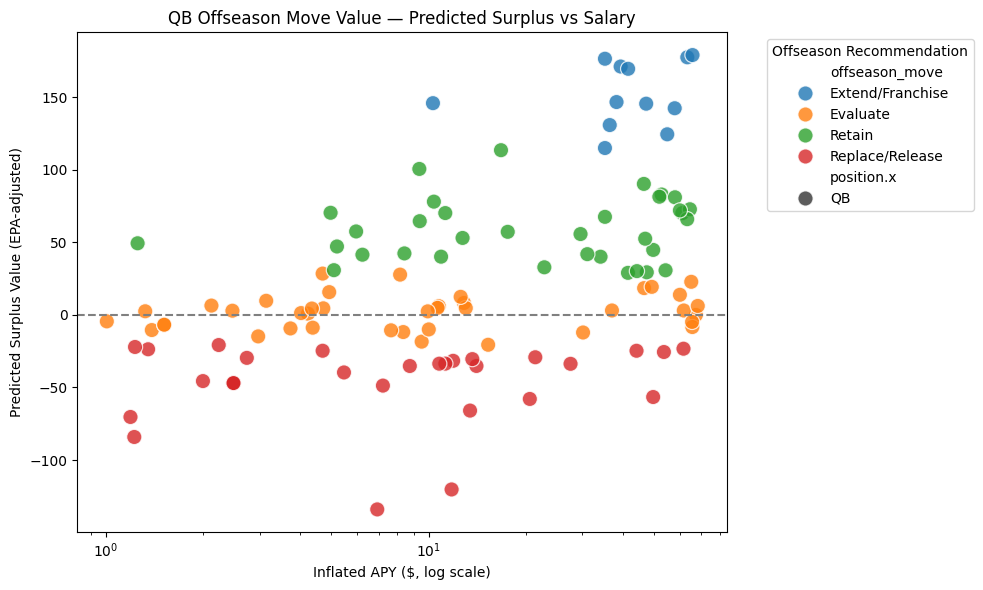

In [ ]:
#Visualization: Offseason Decision Map
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data_ml,
    x="inflated_apy",
    y="predicted_surplus",
    hue="offseason_move",
    style="position.x",
    alpha=0.8,
    s=120
)
plt.xscale("log")
plt.axhline(0, color="gray", linestyle="--")
plt.title("QB Offseason Move Value — Predicted Surplus vs Salary")
plt.xlabel("Inflated APY ($, log scale)")
plt.ylabel("Predicted Surplus Value (EPA-adjusted)")
plt.legend(title="Offseason Recommendation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
extend_top5 = (
    data_ml[data_ml["offseason_move"] == "Extend"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

valuate_top5 = (
    data_ml[data_ml["offseason_move"] == "Evaluate"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

retain_top5 = (
    data_ml[data_ml["offseason_move"] == "Retain"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

replace_top5 = (
    data_ml[data_ml["offseason_move"] == "Replace/Release"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))


In [ ]:
def print_section(title, df):
    print("\n" + "="*60)
    print(f"   {title}")
    print("="*60)
    print(df.to_string(index=False))
    print("="*60)

print_section(
    "Top 5 Extend Candidates",
    extend_top5[["player_name", "position.x", "season",
                 "predicted_surplus", "offseason_move"]])
print_section(
    "Top 5 Evaluate Candidates",
    valuate_top5[["player_name", "position.x", "season",
                   "predicted_surplus", "offseason_move"]])
print_section(
    "Top 5 Retain Candidates",
    retain_top5[["player_name", "position.x", "season",
                 "predicted_surplus", "offseason_move"]])

print_section(
    "Top 5 Replace / Release Candidates",
    replace_top5[["player_name", "position.x", "season",
                  "predicted_surplus", "offseason_move"]])



   Top 5 Extend Candidates
Empty DataFrame
Columns: [player_name, position.x, season, predicted_surplus, offseason_move]
Index: []

   Top 5 Evaluate Candidates
  player_name position.x  season  predicted_surplus offseason_move
      G.Smith         QB    2022          28.398186       Evaluate
R.Fitzpatrick         QB    2019          27.688644       Evaluate
    J.Herbert         QB    2023          22.738423       Evaluate
    K.Cousins         QB    2024          19.276629       Evaluate
       D.Carr         QB    2023          18.410876       Evaluate

   Top 5 Retain Candidates
player_name position.x  season  predicted_surplus offseason_move
     J.Love         QB    2023         113.382574         Retain
  J.Herbert         QB    2020         100.468497         Retain
  K.Cousins         QB    2020          90.157261         Retain
  A.Rodgers         QB    2018          82.830500         Retain
   R.Wilson         QB    2019          81.331084         Retain

   Top 5 Replace 

**Offseason Trade/Release/FA Value: RBs**

In [ ]:
data_rb

,season,player_name,total_plays,total_yards,total_tds,total_epa,avg_epa_per_play,pass_attempts,completions,pass_yards,...,epa_per_million,yards_per_million,tds_per_million,rush_tds_per_million,fumbles_per_million,yds_carry,epa_z,yards_z,tds_z,cap_efficiency_index
17,2018,A.Peterson,262,1042,7,-35.602394,-0.135887,0,0,0,...,-2.226186e+07,6.515534e+08,4.377038e+06,4.377038e+06,1.250582e+06,4.151394,-1.719976,1.273248,1.190984,0.460000
87,2018,L.Miller,222,991,5,-17.115453,-0.077097,0,0,0,...,NaN,NaN,NaN,NaN,NaN,4.609302,NaN,NaN,NaN,NaN
198,2018,M.Gordon,212,942,12,3.121097,0.014722,0,0,0,...,NaN,NaN,NaN,NaN,NaN,4.663366,NaN,NaN,NaN,NaN
200,2018,D.Johnson,264,942,7,-53.282022,-0.201826,0,0,0,...,-2.601271e+06,4.598920e+07,3.417456e+05,3.417456e+05,9.764161e+04,3.637066,0.228834,-0.909466,-0.934966,0.270000
205,2018,T.Gurley,293,1415,19,21.519084,0.073444,0,0,0,...,9.500888e+05,6.247365e+07,8.388688e+05,8.388688e+05,0.000000e+00,4.879310,0.580854,-0.850049,-0.673062,0.518333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2732,2024,B.Robinson,313,1453,14,11.582820,0.037006,0,0,0,...,NaN,NaN,NaN,NaN,NaN,4.779605,NaN,NaN,NaN,NaN
2744,2024,C.Brown,233,992,7,-8.864979,-0.038047,0,0,0,...,NaN,NaN,NaN,NaN,NaN,4.313043,NaN,NaN,NaN,NaN
2767,2024,D.Achane,211,907,6,-15.403597,-0.073003,0,0,0,...,NaN,NaN,NaN,NaN,NaN,4.467980,NaN,NaN,NaN,NaN
2772,2024,J.Gibbs,269,1517,18,36.236723,0.134709,0,0,0,...,NaN,NaN,NaN,NaN,NaN,5.746212,NaN,NaN,NaN,NaN


In [ ]:
#Estimate Surplus Value (Baseline)
expected_epa = np.log1p(data_rb["inflated_apy"]) * data_rb["avg_epa_per_play"] * 10
data_rb["surplus_value"] = data_rb["total_epa"] - expected_epa


/tmp/ipython-input-3119532147.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rb["surplus_value"] = data_rb["total_epa"] - expected_epa


In [ ]:
#Define Features and Target
model_features_rb = [
     "inflated_apy", "total_epa", "avg_epa_per_play", "epa_z",
    "tds_z", "yac_total","rush_attempts","rush_yards","rush_tds",
    "rush_epa_total", "rush_success_rate", "rush_epa_total","avg_rush_epa",
    "rec_yards", "yac_epa_total","fumbles"
]
data_ml_rb2 = data_rb.dropna(subset=model_features_rb)
X = data_ml_rb2[model_features_rb]
y = data_ml_rb2["surplus_value"]

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

gb = GradientBoostingRegressor(random_state=42, n_estimators=300, max_depth=3)
gb.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=300, random_state=42)

In [ ]:
data_ml_rb2["predicted_surplus"] = gb.predict(X)
r2_val = r2_score(y_test, gb.predict(X_test))

print(f"Offseason Move Value Model R² = {r2_val:.2f}")


Offseason Move Value Model R² = 0.96


/tmp/ipython-input-1263691794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml_rb2["predicted_surplus"] = gb.predict(X)


In [ ]:
#Categorize Offseason Decisions
conditions = [
    (data_ml_rb2["predicted_surplus"] > data_ml_rb2["predicted_surplus"].quantile(0.90)),
    (data_ml_rb2["predicted_surplus"] > data_ml_rb2["predicted_surplus"].quantile(0.60)),
    (data_ml_rb2["predicted_surplus"] > data_ml_rb2["predicted_surplus"].quantile(0.25))
]
choices = ["Extend/Franchise", "Retain", "Evaluate"]

data_ml_rb2["offseason_move"] = np.select(conditions, choices, default="Replace/Release")


/tmp/ipython-input-247014101.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml_rb2["offseason_move"] = np.select(conditions, choices, default="Replace/Release")


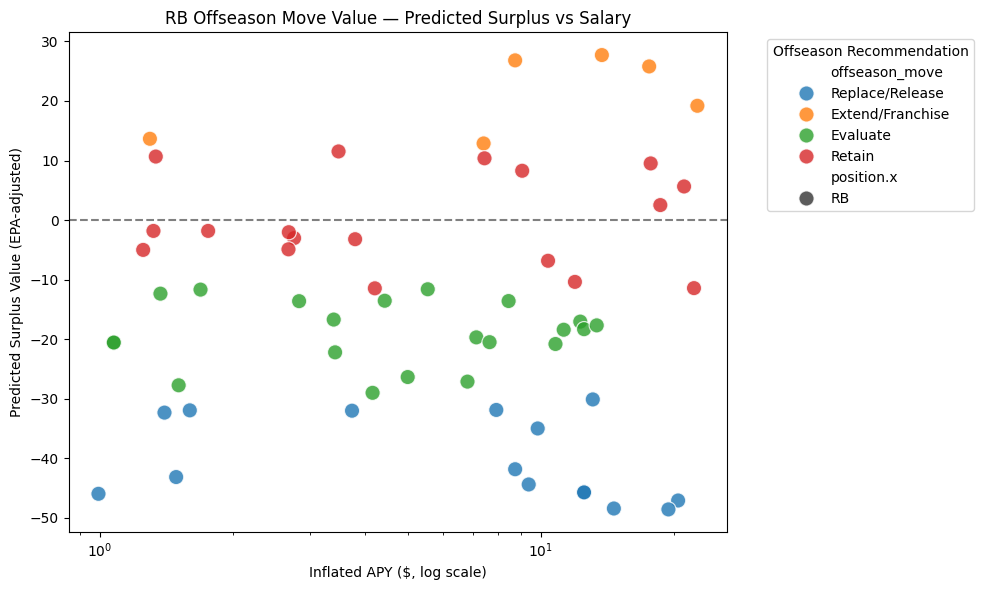

In [ ]:
#Visualization: Offseason Decision Map
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data_ml_rb2,
    x="inflated_apy",
    y="predicted_surplus",
    hue="offseason_move",
    style="position.x",
    alpha=0.8,
    s=120
)
plt.xscale("log")
plt.axhline(0, color="gray", linestyle="--")
plt.title("RB Offseason Move Value — Predicted Surplus vs Salary")
plt.xlabel("Inflated APY ($, log scale)")
plt.ylabel("Predicted Surplus Value (EPA-adjusted)")
plt.legend(title="Offseason Recommendation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
extend_top5 = (
    data_ml_rb2[data_ml_rb2["offseason_move"] == "Extend/Franchise"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

valuate_top5 = (
    data_ml_rb2[data_ml_rb2["offseason_move"] == "Evaluate"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

retain_top5 = (
    data_ml_rb2[data_ml_rb2["offseason_move"] == "Retain"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))

replace_top5 = (
    data_ml_rb2[data_ml_rb2["offseason_move"] == "Replace/Release"]
    .sort_values("predicted_surplus", ascending=False)
    .head(5)
    .reset_index(drop=True))


In [ ]:
def print_section(title, df):
    print("\n" + "="*60)
    print(f"   {title}")
    print("="*60)
    print(df.to_string(index=False))
    print("="*60)

#Top 5 by Offseason Move Category - RB

print_section(
    "Top 5 Extend / Franchise Candidates",
    extend_top5[["player_name", "position.x", "season", "inflated_apy",
                 "predicted_surplus", "offseason_move"]])
print_section(
    "Top 5 Evaluate Candidates",
    valuate_top5[["player_name", "position.x", "season", "inflated_apy",
                   "predicted_surplus", "offseason_move"]])
print_section(
    "Top 5 Retain Candidates",
    retain_top5[["player_name", "position.x", "season", "inflated_apy",
                 "predicted_surplus", "offseason_move"]])

print_section(
    "Top 5 Replace / Release Candidates",
    replace_top5[["player_name", "position.x", "season", "inflated_apy",
                  "predicted_surplus", "offseason_move"]])



   Top 5 Extend / Franchise Candidates
player_name position.x  season  inflated_apy  predicted_surplus   offseason_move
  S.Barkley         RB    2024     13.755938          27.715202 Extend/Franchise
    D.Henry         RB    2024      8.745497          26.823790 Extend/Franchise
    D.Henry         RB    2020     17.608476          25.804979 Extend/Franchise
   T.Gurley         RB    2018     22.649549          19.195818 Extend/Franchise
   B.Irving         RB    2024      1.298584          13.653641 Extend/Franchise

   Top 5 Evaluate Candidates
player_name position.x  season  inflated_apy  predicted_surplus offseason_move
    J.Gibbs         RB    2023      5.540884         -11.615553       Evaluate
 B.Robinson         RB    2022      1.691327         -11.675422       Evaluate
   R.Dowdle         RB    2024      1.371950         -12.355047       Evaluate
   J.Jacobs         RB    2019      4.425884         -13.543333       Evaluate
     K.Hunt         RB    2020      8.452069     